In [1]:
from sklearn.cluster import KMeans
import numpy as np
X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])
kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)


## Real-world example: clustering Iris flowers
We cluster the Iris dataset using K-Means, then visualize clusters with PCA.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load data
iris = load_iris()
X = iris.data

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Reduce to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

# Plot clusters
plt.figure(figsize=(6, 4))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', s=30)
plt.title('K-Means Clusters on Iris (PCA Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# Optional: inspect cluster centers in original feature space
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print('Cluster centers (approx. original units):')
print(np.round(centers, 2))


## Real use case: retail store customer segmentation (step by step)
We segment customers using simple retail behaviors: recency, frequency, and monetary value.

**Steps**
1. Build a customer feature table (recency, purchase frequency, average basket size).
2. Scale features so one metric does not dominate the others.
3. Run K-Means to form segments.
4. Visualize segments and summarize each group.


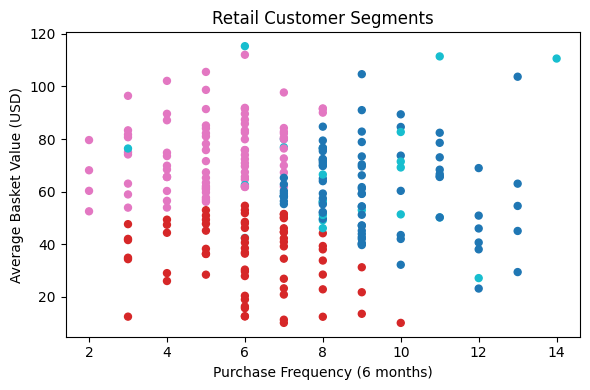

         recency_days  frequency_6mo  avg_basket_usd  customers
segment                                                        
0               23.32           9.26           61.08         80
1               27.35           6.09           35.15         67
2               27.34           5.11           75.04         81
3               78.77           8.55           67.36         22


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1) Create a simple retail-style dataset (synthetic for demo)
rng = np.random.default_rng(42)
n_customers = 250

# Recency: days since last purchase (lower is better)
recency = rng.gamma(shape=2.0, scale=15.0, size=n_customers)

# Frequency: number of purchases in last 6 months
frequency = rng.poisson(lam=6.0, size=n_customers) + 1

# Monetary: average basket value in USD
monetary = rng.normal(loc=60.0, scale=20.0, size=n_customers)
monetary = np.clip(monetary, 10, None)

retail = pd.DataFrame({
    'recency_days': recency,
    'frequency_6mo': frequency,
    'avg_basket_usd': monetary,
})

# 2) Scale features
scaler = StandardScaler()
X = scaler.fit_transform(retail)

# 3) Fit K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
retail['segment'] = labels

# 4) Visualize segments (frequency vs. monetary)
plt.figure(figsize=(6, 4))
plt.scatter(retail['frequency_6mo'], retail['avg_basket_usd'], c=labels, cmap='tab10', s=25)
plt.title('Retail Customer Segments')
plt.xlabel('Purchase Frequency (6 months)')
plt.ylabel('Average Basket Value (USD)')
plt.tight_layout()
plt.show()

# Segment summary for business interpretation
summary = retail.groupby('segment').agg({
    'recency_days': 'mean',
    'frequency_6mo': 'mean',
    'avg_basket_usd': 'mean',
    'segment': 'count'
}).rename(columns={'segment': 'customers'})

print(summary.round(2))


In [ ]:
# https://www.kaggle.com/code/abdallah3gag/customer-segmentation-clustering ( optional )
#http://www.saedsayad.com/clustering_kmeans.htm ( please refer this one )
# https://web.iitd.ac.in/~bspanda/clustering.pdf
# https://www.cse.iitm.ac.in/~vplab/courses/SLT/PDF/CSLT-CLUSTERING_Apr-23.pdf